# Tarea grupal — IA en Producción — Grupo 5
## Puntos 3 y 4 — Gráficos de resumen y Limpieza de teléfono/anexo

**Integrante:** Mario Poblete
**Rama:** Mario-Poblete

Este notebook es **autocontenido**: incluye su propia carga de librerías y del archivo
`plan_de_compras_2025.xlsx`, y recalcula internamente cualquier tabla auxiliar que necesita
(por ejemplo, los totales por unidad de compra o por responsable usados en los gráficos), por
lo que puede ejecutarse de forma independiente (`Kernel > Restart & Run All`) sin depender de
ningún otro notebook del equipo.


## 0. Carga de librerías y datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
ARCHIVO = 'plan_de_compras_2025.xlsx'

df = pd.read_excel(ARCHIVO, sheet_name='PLAN DE COMPRAS 2025')
print('Dimensiones del dataset:', df.shape)
df.head()

Dimensiones del dataset: (831, 26)


,Unidad de Compra,ID Proyecto,Tipo Proyecto,Estado Proyecto,Código presupuestario,Nombre Proyecto,Descripción Proyecto,Cantidad de Ítems,Nombre ítem,Tipo compra,Cantidad Productos,Monto Unitario Ítem,Monto Total Ítem Año 2025,Cantidad OC,Meses envío OC,Nombre responsable,Cargo responsable,Teléfono responsable,Correo responsable,Fecha de Inicio Compra,Fecha Publicación PAC 2025,Cantidad OC Asociadas Ítem 2025,OC Asociada Item 2025,Item De Arraste,Monto De Arrastre,Meses envio OC de Arraste
0,Ministerio de Vivienda y Urbanismo(766),587-259-PC22,Proyecto estratégico,Publicado,2207-2209-33,Servicio arriendo de una plataforma de gestión...,Servicio de arriendo de una plataforma de gest...,2,Servicio arriendo de una plataforma de gestión...,1,1,125000000,20000000,3,"Abr 2023,Ene 2024,Ene 2025",María Teresa Zúñiga Silva,Coordinadora de Tecnologías Informáticas | Sis...,2 -2901 1198-,mzunigas@minvu.cl,2022-11-01,2022-11-08,0,NaN,1,20000000,2025-01-01
1,SEREMI MINVU V REGION,632-28-PC22,Proyecto operacional,Publicado,2206-2206001,Servicio de Mantención y Reparaciones Menores ...,Convenio de Suministro para el Servicio de Man...,1,Mantenimiento y Reparación de Edificaciones,1,1,20000000,4500000,5,"May 2022,Nov 2022,Ene 2023,Ene 2024,Ene 2025",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-02-01,2022-11-08,1,632-7-SE22,1,4500000,2025-01-01
2,SEREMI MINVU V REGION,632-32-PC22,Proyecto operacional,Publicado,2204001,Servicios de Impresión-Seremi Valparaiso,Servicios de Impresión de Materiales SEREMI y ...,1,Materiales de Oficina,1,1,15300000,3825000,4,"Oct 2022,Ene 2023,Ene 2024,Ene 2025",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-08-01,2022-11-08,0,NaN,1,3825000,2025-01-01
3,SEREMI MINVU V REGION,632-34-PC22,Proyecto operacional,Publicado,2209006,Servicio de Arriendo de Impresoras Multifuncio...,Servicio de Arriendo de Impresoras Multifuncio...,2,Arriendo de Equipos Informáticos,1,1,18000000,4500000,6,"Oct 2022,Nov 2022,Dic 2022,Ene 2023,Ene 2024,E...",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,32-2186802-,agardaix@minvu.cl,2022-08-01,2022-11-08,1,632-13-CC23,1,4500000,2025-01-01
4,SEREMI MINVU V REGION,632-41-PC22,Proyecto operacional,Publicado,2205005,Servicio de Telefonía Fija-Seremi Valparaiso,Servicio de Telefonía Fija SEREMI,2,Telefonía Fija,1,1,105600000,26400000,4,"Ene 2023,Ene 2024,Ene 2025,Ene 2026",Ariel Gardaix Gardaix,Encargado Sección Administración y Finanzas,322186802,agardaix@minvu.cl,2022-12-01,2022-11-08,0,NaN,1,26400000,2025-01-01


## 3. Gráficos de resumen (5)

Cinco visualizaciones que resumen visualmente el plan de compras 2025. Las tablas de apoyo
necesarias para cada gráfico se calculan aquí mismo, de forma autocontenida.

### Gráfico 1 — Top 10 Unidades de Compra por monto total

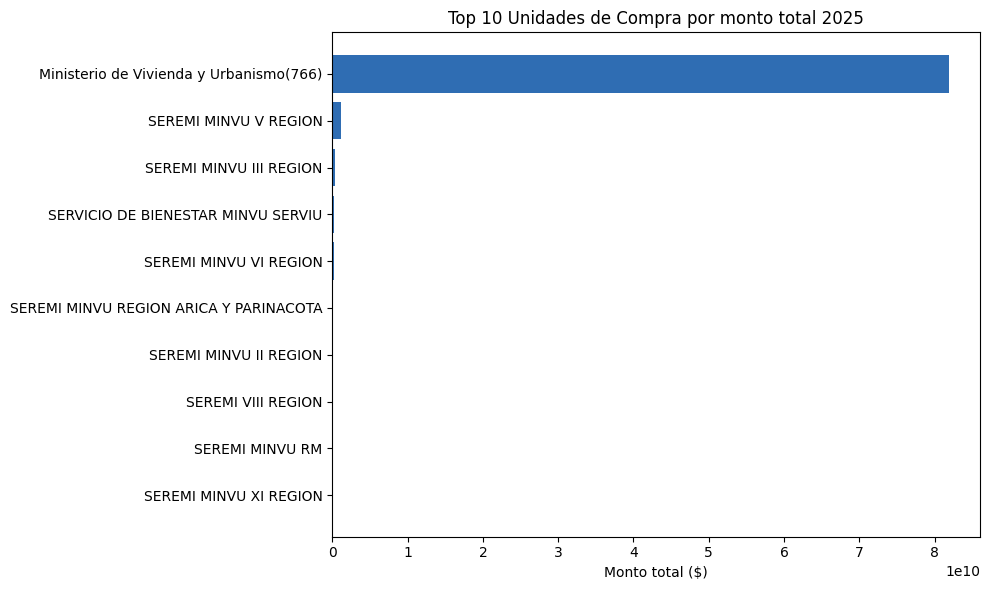

In [3]:
monto_por_unidad = (
    df.groupby('Unidad de Compra', dropna=False)['Monto Total Ítem Año 2025']
    .sum()
    .sort_values(ascending=False)
)
top10_unidades = monto_por_unidad.head(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10_unidades.index.astype(str), top10_unidades.values, color='#2f6db3')
ax.set_xlabel('Monto total ($)')
ax.set_title('Top 10 Unidades de Compra por monto total 2025')
plt.tight_layout()
plt.show()

### Gráfico 2 — Top 10 responsables por monto gestionado

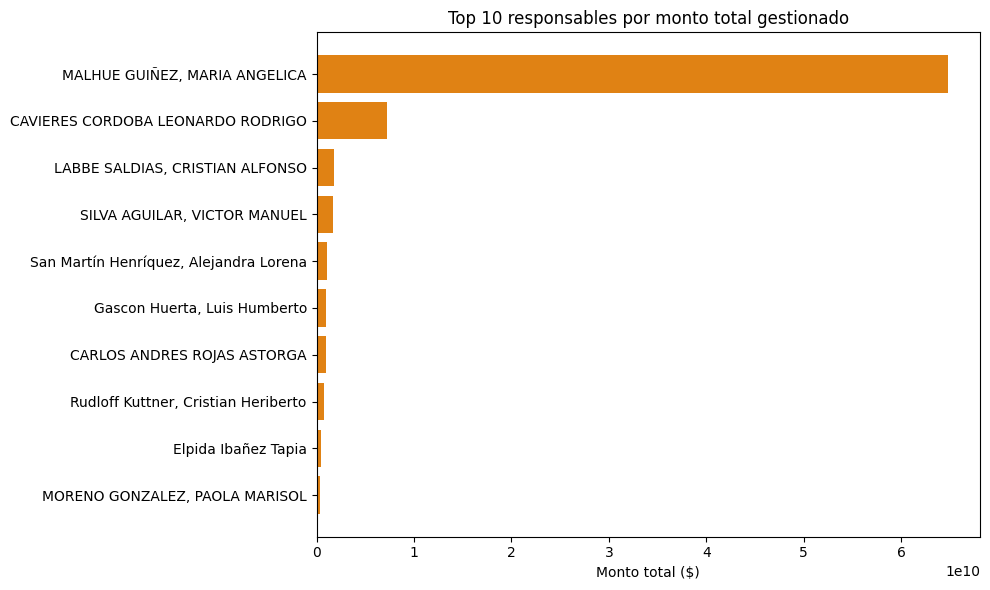

In [4]:
monto_por_responsable = (
    df.groupby('Nombre responsable', dropna=False)['Monto Total Ítem Año 2025']
    .sum()
    .sort_values(ascending=False)
)
top10_resp = monto_por_responsable.head(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top10_resp.index.astype(str), top10_resp.values, color='#e08214')
ax.set_xlabel('Monto total ($)')
ax.set_title('Top 10 responsables por monto total gestionado')
plt.tight_layout()
plt.show()

### Gráfico 3 — Distribución de proyectos por tipo

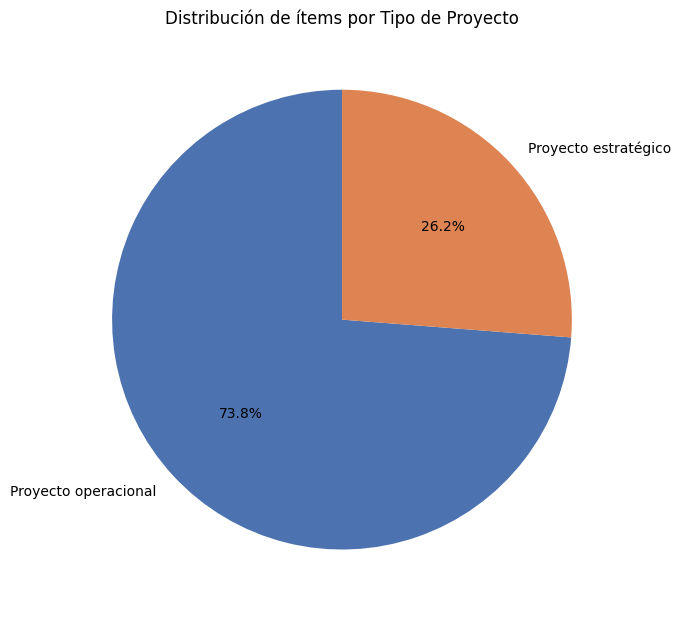

In [5]:
dist_tipo = df['Tipo Proyecto'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(dist_tipo.values, labels=dist_tipo.index, autopct='%1.1f%%', startangle=90,
       colors=['#4c72b0', '#dd8452'])
ax.set_title('Distribución de ítems por Tipo de Proyecto')
plt.tight_layout()
plt.show()

### Gráfico 4 — Distribución del monto unitario por ítem

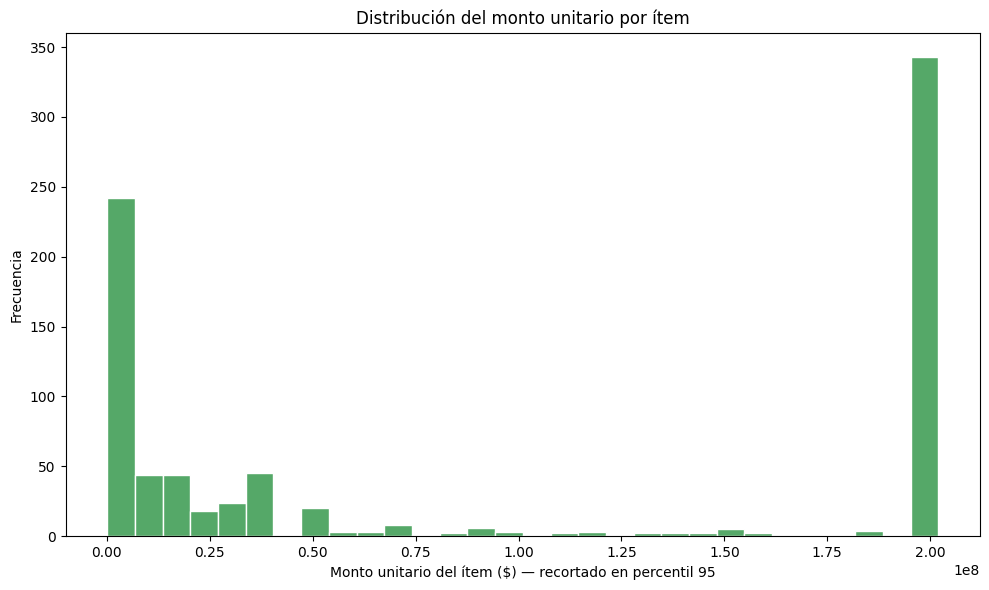

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
datos_hist = df['Monto Unitario Ítem'].clip(upper=df['Monto Unitario Ítem'].quantile(0.95))
ax.hist(datos_hist, bins=30, color='#55a868', edgecolor='white')
ax.set_xlabel('Monto unitario del ítem ($) — recortado en percentil 95')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución del monto unitario por ítem')
plt.tight_layout()
plt.show()

### Gráfico 5 — Evolución mensual del monto comprometido

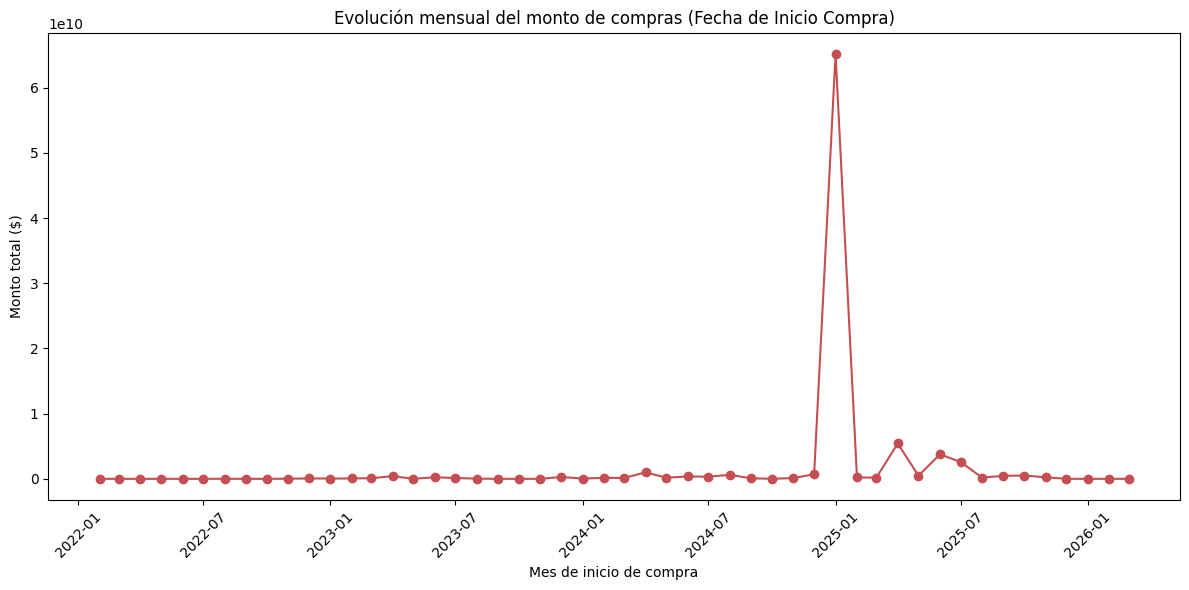

In [7]:
serie_mensual = (
    df.set_index('Fecha de Inicio Compra')
    .resample('MS')['Monto Total Ítem Año 2025']
    .sum()
)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(serie_mensual.index, serie_mensual.values, marker='o', color='#c44e52')
ax.set_xlabel('Mes de inicio de compra')
ax.set_ylabel('Monto total ($)')
ax.set_title('Evolución mensual del monto de compras (Fecha de Inicio Compra)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Limpieza de columna teléfono

La columna `Teléfono responsable` viene con formatos muy inconsistentes: espacios, guiones y, en algunos
casos, un anexo repetido al final separado por un segundo guion (ej. `'22-9011325-1325'`).

**Estrategia de limpieza:**
1. Se separa el valor original por guion (`-`), tomando como **anexo** la tercera parte (si existe), dejando solo dígitos y quedándonos con los últimos 4.
2. Se limpia la columna `Teléfono responsable` eliminando **todos los espacios y guiones**, dejando solo el número.
3. Los valores vacíos o `'0'` se transforman a `NaN` (dato faltante), ya que no representan un teléfono válido.


In [8]:
# Guardamos el original para comparar antes/después
df['Teléfono responsable (original)'] = df['Teléfono responsable']

telefono_str = df['Teléfono responsable'].fillna('').astype(str).str.strip()
partes_telefono = telefono_str.str.split('-', n=2)

# Anexo: tercera parte del split (si existe), solo dígitos, últimos 4 dígitos
df['Anexo'] = (
    partes_telefono.str[2]
    .fillna('')
    .str.replace(r'\D', '', regex=True)
    .str[-4:]
)
df.loc[df['Anexo'] == '', 'Anexo'] = np.nan

# Teléfono limpio: se quitan espacios y guiones
df['Teléfono responsable'] = telefono_str.str.replace(r'[\s\-]+', '', regex=True)
df.loc[df['Teléfono responsable'].isin(['', '0']), 'Teléfono responsable'] = np.nan

df[['Teléfono responsable (original)', 'Teléfono responsable', 'Anexo']].head(15)

,Teléfono responsable (original),Teléfono responsable,Anexo
0,2 -2901 1198-,229011198,NaN
1,32-2186802-,322186802,NaN
2,32-2186802-,322186802,NaN
3,32-2186802-,322186802,NaN
4,322186802,322186802,NaN
5,02-29011184-,0229011184,NaN
6,22-901727-,22901727,NaN
7,0,NaN,NaN
8,0,NaN,NaN
9,22901727,22901727,NaN


In [9]:
print('Teléfonos válidos:', df['Teléfono responsable'].notna().sum(), 'de', len(df))
print('Anexos identificados:', df['Anexo'].notna().sum())

# limpiamos la columna auxiliar de comparación
df = df.drop(columns=['Teléfono responsable (original)'])
df[['Teléfono responsable', 'Anexo']].head(15)

Teléfonos válidos: 817 de 831
Anexos identificados: 84


,Teléfono responsable,Anexo
0,229011198,NaN
1,322186802,NaN
2,322186802,NaN
3,322186802,NaN
4,322186802,NaN
5,0229011184,NaN
6,22901727,NaN
7,NaN,NaN
8,NaN,NaN
9,22901727,NaN


## Resumen

- **Gráficos:** 5 visualizaciones (unidades de compra, responsables, tipo de proyecto, distribución de montos, evolución mensual).
- **Teléfono/anexo:** se separó el anexo en columna propia y se limpiaron espacios/guiones del teléfono.
